# 03 Exploratory Data Analysis (EDA)

**Objective:** Explore the cleaned hospital readmissions dataset, uncover patterns, identify high-risk patient groups, and generate business insights for reducing short-term readmissions.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
warnings = __import__('warnings')
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/processed/cleaned_data.csv')
df.head()

Matplotlib is building the font cache; this may take a moment.


,patient_id,age,gender,cholesterol,bmi,diabetes,hypertension,medication_count,length_of_stay,discharge_destination,readmitted_30_days,systolic_bp,diastolic_bp,is_readmitted,age_group,stay_category,risk_tier
0,1.0,74.0,other,240.0,31.5,yes,no,5.0,1.0,nursing_facility,yes,130.0,72.0,1,senior,short,medium
1,2.0,46.0,female,292.0,36.3,no,no,4.0,3.0,nursing_facility,no,120.0,92.0,0,adult,short,low
2,3.0,89.0,other,153.0,30.3,no,yes,1.0,1.0,home,no,135.0,78.0,0,senior,short,medium
3,4.0,84.0,female,226.0,31.5,no,yes,3.0,10.0,home,no,123.0,80.0,0,senior,long,high
4,5.0,32.0,other,205.0,18.4,no,yes,6.0,4.0,nursing_facility,no,135.0,84.0,0,young,medium,low


## Dataset Overview

In [5]:
print('Shape:', df.shape)
df.info()
df.describe(include='all')

Shape: (30224, 17)
<class 'pandas.DataFrame'>
RangeIndex: 30224 entries, 0 to 30223
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   patient_id             30224 non-null  float64
 1   age                    30224 non-null  float64
 2   gender                 30224 non-null  str    
 3   cholesterol            30224 non-null  float64
 4   bmi                    30224 non-null  float64
 5   diabetes               30224 non-null  str    
 6   hypertension           30224 non-null  str    
 7   medication_count       30224 non-null  float64
 8   length_of_stay         30224 non-null  float64
 9   discharge_destination  30224 non-null  str    
 10  readmitted_30_days     30224 non-null  str    
 11  systolic_bp            30224 non-null  float64
 12  diastolic_bp           30224 non-null  float64
 13  is_readmitted          30224 non-null  int64  
 14  age_group              30224 non-null  str    

,patient_id,age,gender,cholesterol,bmi,diabetes,hypertension,medication_count,length_of_stay,discharge_destination,readmitted_30_days,systolic_bp,diastolic_bp,is_readmitted,age_group,stay_category,risk_tier
count,30224.000000,30224.000000,30224,30224.000000,30224.00000,30224,30224,30224.000000,30224.000000,30224,30224,30224.000000,30224.000000,30224.000000,30224,30224,30224
unique,NaN,NaN,3,NaN,NaN,2,2,NaN,NaN,3,2,NaN,NaN,NaN,3,4,3
top,NaN,NaN,male,NaN,NaN,no,no,NaN,NaN,home,no,NaN,NaN,NaN,adult,medium,medium
freq,NaN,NaN,11178,NaN,NaN,15873,15895,NaN,NaN,21477,26711,NaN,NaN,NaN,13463,12842,22489
mean,16365.300490,53.861501,NaN,226.753375,28.95753,NaN,NaN,5.134595,5.630393,NaN,NaN,134.978395,85.036627,0.116232,NaN,NaN,NaN
std,15867.806259,20.424781,NaN,44.912193,6.14924,NaN,NaN,3.297502,2.959465,NaN,NaN,14.303306,8.688464,0.320508,NaN,NaN,NaN
min,1.000000,18.000000,NaN,150.000000,18.00000,NaN,NaN,0.000000,1.000000,NaN,NaN,110.000000,70.000000,0.000000,NaN,NaN,NaN
25%,7998.750000,37.000000,NaN,190.000000,23.80000,NaN,NaN,2.000000,3.000000,NaN,NaN,123.000000,78.000000,0.000000,NaN,NaN,NaN
50%,15148.000000,54.000000,NaN,226.000000,28.90000,NaN,NaN,5.000000,6.000000,NaN,NaN,135.000000,85.000000,0.000000,NaN,NaN,NaN
75%,22321.250000,71.000000,NaN,262.000000,34.20000,NaN,NaN,8.000000,8.000000,NaN,NaN,147.000000,92.000000,0.000000,NaN,NaN,NaN


## Target Variable Analysis

In [6]:
target_counts = df['readmitted_30_days'].value_counts()
target_percentage = df['readmitted_30_days'].value_counts(normalize=True)*100
print(target_counts)
print(target_percentage)

readmitted_30_days
no     26711
yes     3513
Name: count, dtype: int64
readmitted_30_days
no     88.376787
yes    11.623213
Name: proportion, dtype: float64


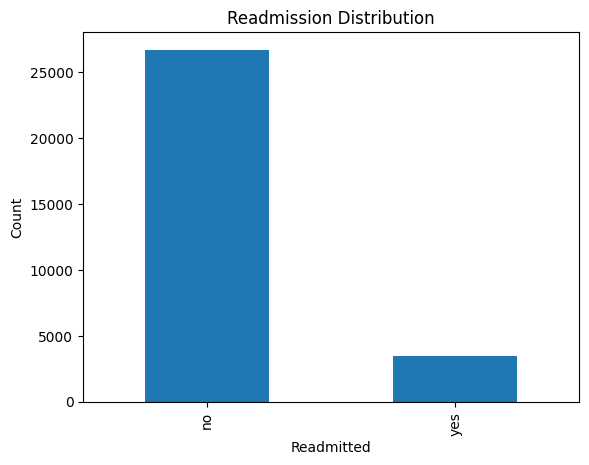

In [7]:
target_counts.plot(kind='bar')
plt.title('Readmission Distribution')
plt.xlabel('Readmitted')
plt.ylabel('Count')
plt.show()

## Age Analysis

In [8]:
df['age'].describe()

count    30224.000000
mean        53.861501
std         20.424781
min         18.000000
25%         37.000000
50%         54.000000
75%         71.000000
max         90.000000
Name: age, dtype: float64

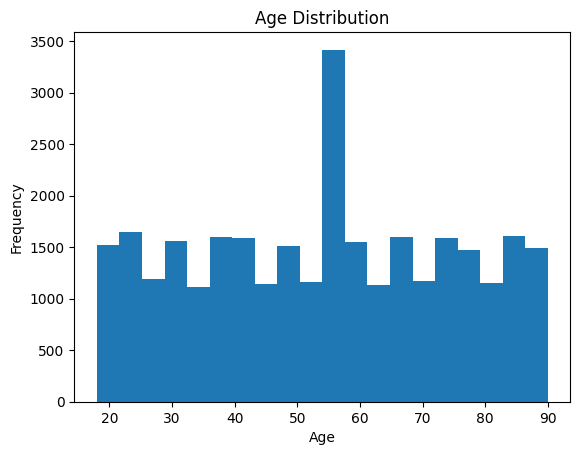

In [9]:
plt.hist(df['age'], bins=20)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

## Length of Stay Analysis

In [10]:
df['length_of_stay'].describe()

count    30224.000000
mean         5.630393
std          2.959465
min          1.000000
25%          3.000000
50%          6.000000
75%          8.000000
max         15.500000
Name: length_of_stay, dtype: float64

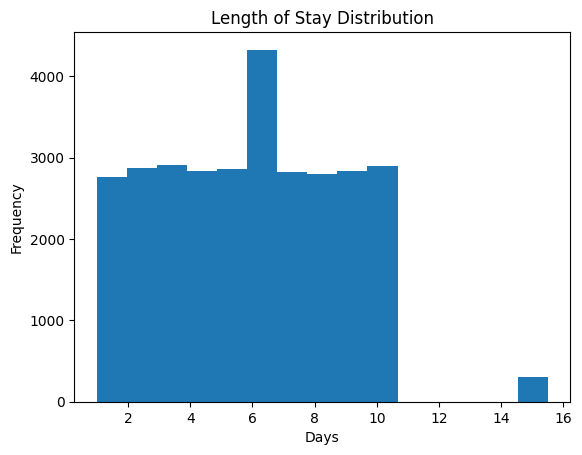

In [11]:
plt.hist(df['length_of_stay'], bins=15)
plt.title('Length of Stay Distribution')
plt.xlabel('Days')
plt.ylabel('Frequency')
plt.show()

## Readmission by Age Group

In [12]:
age_readmission = pd.crosstab(df['age_group'], df['readmitted_30_days'])
age_readmission

readmitted_30_days,no,yes
age_group,,
adult,11893,1570
senior,8912,1171
young,5906,772


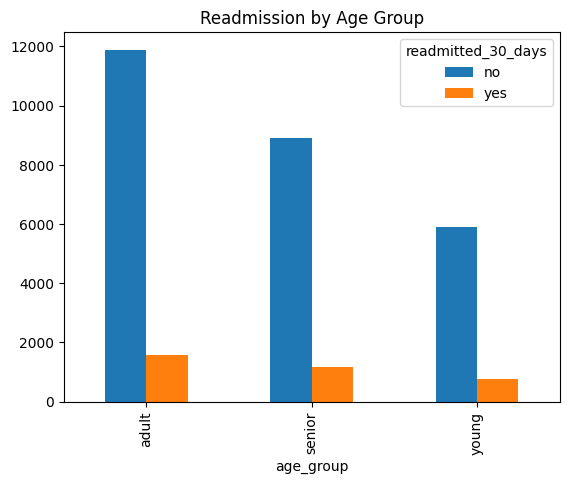

In [13]:
age_readmission.plot(kind='bar')
plt.title('Readmission by Age Group')
plt.show()

## Chronic Conditions Impact

In [14]:
diabetes_readmission = pd.crosstab(df['diabetes'], df['readmitted_30_days'])
hypertension_readmission = pd.crosstab(df['hypertension'], df['readmitted_30_days'])
print(diabetes_readmission)
print(hypertension_readmission)

readmitted_30_days     no   yes
diabetes                       
no                  14156  1717
yes                 12555  1796
readmitted_30_days     no   yes
hypertension                   
no                  14148  1747
yes                 12563  1766


## Risk Tier Analysis

In [15]:
risk_analysis = pd.crosstab(df['risk_tier'], df['readmitted_30_days'])
risk_analysis

readmitted_30_days,no,yes
risk_tier,,
high,2425,320
low,4390,600
medium,19896,2593


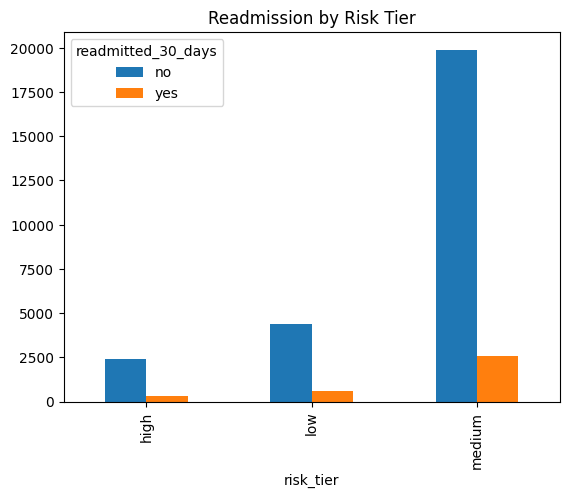

In [16]:
risk_analysis.plot(kind='bar')
plt.title('Readmission by Risk Tier')
plt.show()

## Correlation Analysis

In [17]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])
corr = numeric_df.corr()
corr

,patient_id,age,cholesterol,bmi,medication_count,length_of_stay,systolic_bp,diastolic_bp,is_readmitted
patient_id,1.000000,0.001313,0.285578,-0.002577,0.306693,0.287138,0.002336,0.003580,-0.001971
age,0.001313,1.000000,-0.005921,0.004429,0.001522,0.002701,-0.014536,-0.003553,0.002409
cholesterol,0.285578,-0.005921,1.000000,-0.004086,0.123022,0.118774,-0.005647,0.004076,0.000874
bmi,-0.002577,0.004429,-0.004086,1.000000,0.006010,-0.001150,-0.004237,-0.007323,-0.012598
medication_count,0.306693,0.001522,0.123022,0.006010,1.000000,0.127973,-0.000130,0.005874,-0.000903
length_of_stay,0.287138,0.002701,0.118774,-0.001150,0.127973,1.000000,0.004780,0.006013,-0.006142
systolic_bp,0.002336,-0.014536,-0.005647,-0.004237,-0.000130,0.004780,1.000000,0.007829,0.000396
diastolic_bp,0.003580,-0.003553,0.004076,-0.007323,0.005874,0.006013,0.007829,1.000000,-0.002717
is_readmitted,-0.001971,0.002409,0.000874,-0.012598,-0.000903,-0.006142,0.000396,-0.002717,1.000000


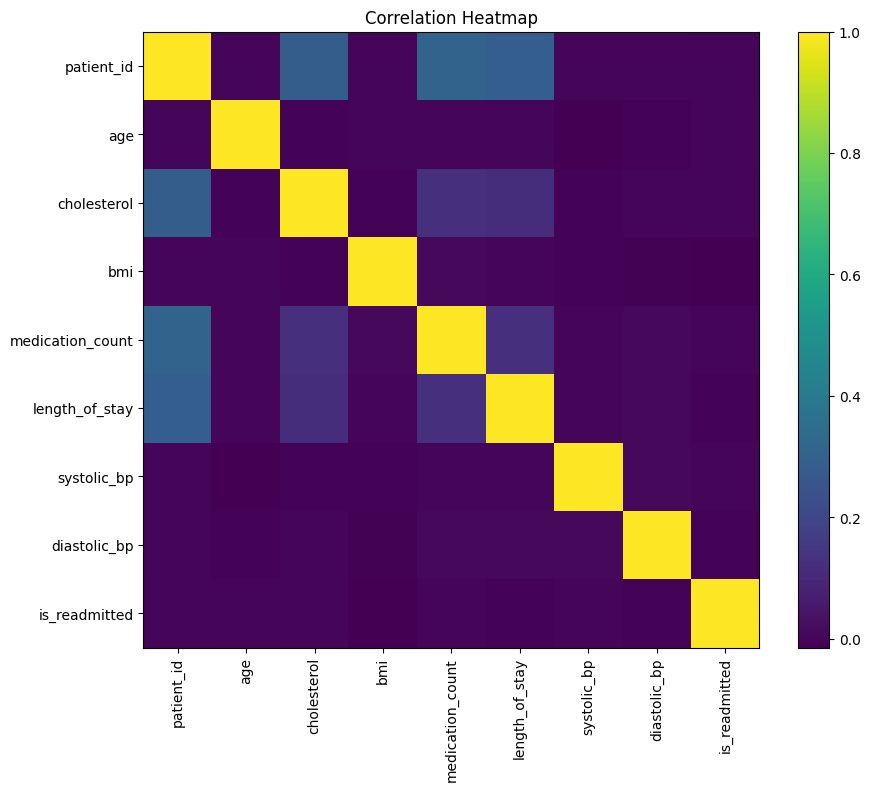

In [18]:
plt.figure(figsize=(10,8))
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title('Correlation Heatmap')
plt.show()

## Final Insights
Write your findings here after running the notebook:
- Which age group has highest readmission?
- Does longer stay increase readmission?
- Do diabetes and hypertension affect outcomes?
- Which risk tier is most vulnerable?